In [6]:
import cv2
from PIL import Image

path = '/workdir/radish/hachi/OBJ_INS/phase2_V2/train/20_b2/ground_truth.jpg'
img1 = cv2.imread(path)
img2 = Image.open(path)

In [7]:
img1.shape

(384, 512, 3)

In [9]:
img2.size

(512, 384)

In [25]:
import cv2
import numpy as np
from PIL import Image, ImageDraw

In [22]:
def augment_images(img_path, mask_bbox, loc_bbox, resolution):
    """
    Crop và resize img về kích thước resolution, thay đổi tọa độ bbox tương ứng.
    Đảm bảo crop vào phần có mask_bbox và loc_bbox
    parameters:
        img_path: path to img
        mask_bbox, loc_bbox: (x1, y1, x2, y2) theo tọa độ ảnh gốc
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Kích thước hình vuông crop
    square_size = min(h, w)
    half = square_size // 2

    # Hai bbox cần đảm bảo nằm trong crop
    bboxes = np.array([mask_bbox, loc_bbox])

    # Tìm min/max của toàn bộ vùng cần cover
    x_min = np.min(bboxes[:, 0])
    y_min = np.min(bboxes[:, 1])
    x_max = np.max(bboxes[:, 2])
    y_max = np.max(bboxes[:, 3])

    # Tâm ban đầu
    cx = (x_min + x_max)/2
    cy = (y_min + y_max)/2

    # Crop ban đầu
    crop_x1 = int(cx - half)
    crop_y1 = int(cy-half)
    crop_x2 = crop_x1 + square_size
    crop_y2 = crop_y1 + square_size

    # Hàm dịch crop vào trong ảnh
    def shift_into_image(x1, y1, x2, y2, W, H):
        dx1 = max(0, -x1)
        dy1 = max(0, -y1)
        dx2 = max(0, x2 - W)
        dy2 = max(0, y2 - H)
        return x1 + dx1 - dx2, y1 + dy1 - dy2, x2 + dx1 - dx2, y2 + dy1 - dy2

    crop_x1, crop_y1, crop_x2, crop_y2 = shift_into_image(
        crop_x1, crop_y1, crop_x2, crop_y2, w, h
    )

    # Kiểm tra đảm bảo chứa đủ bbox
    for (bx1, by1, bx2, by2) in bboxes:
        if not (crop_x1 <= bx1 and bx2 <= crop_x2 and crop_y1 <= by1 and by2 <= crop_y2):
            logger.info(f"{img_path} Bbox quá to, không thể chứa trong crop hình vuông min(h,w).")

    # Crop
    crop = img[crop_y1:crop_y2, crop_x1:crop_x2]

    # Resize
    resized = cv2.resize(crop, (resolution, resolution))
    scale = resolution/square_size

    # Chuyển toạ độ bbox
    def convert_bbox(bbox):
        x1, y1, x2, y2 = bbox
        x1 = int((x1 - crop_x1) * scale)
        y1 = int((y1 - crop_y1) * scale)
        x2 = int((x2 - crop_x1) * scale)
        y2 = int((y2 - crop_y1) * scale)
        return [x1, y1, x2, y2]

    new_mask_bbox = convert_bbox(mask_bbox)
    new_loc_bbox = convert_bbox(loc_bbox)

    # Tạo mask
    mask = np.zeros((resolution, resolution), dtype=np.uint8)
    x1, y1, x2, y2 = new_mask_bbox
    mask[y1:y2, x1:x2] = 255

    return resized, mask, new_mask_bbox, new_loc_bbox

In [32]:
path = '/workdir/radish/hachi/OBJ_INS/phase2_V2/train/7_b2/ground_truth.jpg'
mask_bbox =  [
      301,
      194,
      331,
      218
    ]
loc_bbox = [
      56,
      137,
      74,
      164
    ]

img, mask, mb, lb = augment_images(path, mask_bbox, loc_bbox, 512)

In [35]:
type(mask)

numpy.ndarray

In [37]:
img.shape

(512, 512, 3)

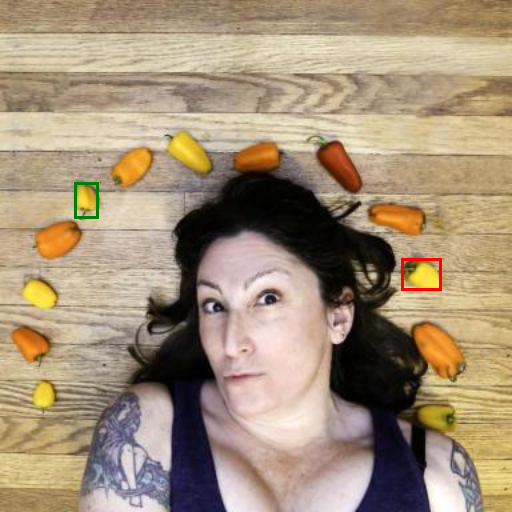

In [33]:
img1 = Image.fromarray(img)
draw = ImageDraw.Draw(img1)
draw.rectangle(mb, outline='red', width=3)
draw.rectangle(lb, outline='green', width=3)
img1